In [1]:
# Cell 1
import numpy as np
from scipy.linalg import qr, rq, svd
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt
import os

# Create the directory for saving figures
os.makedirs("figureAKLT", exist_ok=True)

def TruncateBond(M, D_max, eps_rel, eps_abs=1e-14):
    """Algorithm 3: SVD Truncation algorithm"""
    u, s, vh = svd(M, full_matrices=False)
    
    # Ensure descending order (scipy usually does this, but safely guarantee it)
    if s[0] < s[-1]:
        s = s[::-1]
        u = u[:, ::-1]
        vh = vh[::-1, :]
        
    if s[0] < eps_abs:
        D = 1
    else:
        threshold = max(eps_rel * s[0], eps_abs)
        D = min(D_max, np.sum(s > threshold))
        D = max(D, 1) # Always keep at least one state
        
    eta = np.sum(s[D:]**2) if D < len(s) else 0.0
    return u[:, :D], s[:D], vh[:D, :], eta

def generate_random_mps(L, d, D):
    """Helper to generate a random MPS initialized with complex128"""
    MPS = []
    for i in range(1, L+1):
        D_left = 1 if i == 1 else D
        D_right = 1 if i == L else D
        M = np.random.randn(D_left, d, D_right) + 1j * np.random.randn(D_left, d, D_right)
        MPS.append(M)
    return MPS

In [2]:
# Cell 2
def LeftCanonicalize(M_list):
    """Algorithm 1: Left canonicalization via QR"""
    L = len(M_list)
    A = []
    C = np.ones((1, 1), dtype=np.complex128)
    
    for i in range(L-1):
        M_tilde = np.einsum('xy,ysa->xsa', C, M_list[i])
        dimL, d, dimR = M_tilde.shape
        M_mat = M_tilde.reshape(dimL * d, dimR)
        
        Q, R = qr(M_mat, mode='economic')
        A.append(Q.reshape(dimL, d, Q.shape[1]))
        C = R
        
    M_tilde = np.einsum('xy,ysa->xsa', C, M_list[-1])
    A.append(M_tilde)
    return A

def RightCanonicalize(M_list):
    """Algorithm 2: Right canonicalization via RQ"""
    L = len(M_list)
    B = [None] * L
    C = np.ones((1, 1), dtype=np.complex128)
    
    for i in range(L-1, 0, -1):
        M_tilde = np.einsum('xsa,ay->xsy', M_list[i], C)
        dimL, d, dimR = M_tilde.shape
        M_mat = M_tilde.reshape(dimL, d * dimR)
        
        R, Q = rq(M_mat, mode='economic')
        B[i] = Q.reshape(R.shape[1], d, dimR)
        C = R
        
    M_tilde = np.einsum('xsa,ay->xsy', M_list[0], C)
    B[0] = M_tilde
    return B

In [3]:
# Cell 3
def ComputeOverlap(M1, M2):
    """Algorithm 4: Overlap <M1|M2>"""
    E = np.ones((1, 1), dtype=np.complex128)
    for i in range(len(M1)):
        E = np.einsum('xy,xsa,ysb->ab', E, M1[i].conj(), M2[i])
    return E[0, 0]

def ApplyMPOtoMPS(W, M):
    """Algorithm 5: Apply MPO to MPS (yields bond dimension D_W * D_psi)"""
    phi = []
    for i in range(len(M)):
        # W[i] shape: (b, B, s_out, s_in)
        # M[i] shape: (x, s_in, y)
        # Contract over s_in (t). 
        # CRITICAL FIX: Ensure B and y are both on the right hand side to avoid summing them out!
        T = np.einsum('bBst,xty->bxsBy', W[i], M[i])
        
        # Merge left bonds (b, x) and right bonds (B, y) sequentially
        new_dimL = W[i].shape[0] * M[i].shape[0]
        new_dimR = W[i].shape[1] * M[i].shape[2]
        d_out = W[i].shape[2]
        
        # T has shape (b, x, s_out, B, y). Reshaping flattens b*x and B*y exactly.
        phi.append(T.reshape(new_dimL, d_out, new_dimR))
    return phi

def ComputeVariance(M, W, E):
    """Algorithm 12: Compute energy variance sigma^2"""
    phi = ApplyMPOtoMPS(W, M)
    H2 = ComputeOverlap(phi, phi).real
    norm2 = ComputeOverlap(M, M).real
    return (H2 / norm2) - E**2

In [4]:
# Cell 4
def BuildHeisenbergMPO(L, J=1.0, h=0.0):
    """Section 6.1: Heisenberg Model MPO (This one in the notes is analytically correct)"""
    I = np.eye(2, dtype=np.complex128)
    Sp = np.array([[0, 1], [0, 0]], dtype=np.complex128)
    Sm = np.array([[0, 0], [1, 0]], dtype=np.complex128)
    Sz = np.array([[0.5, 0], [0, -0.5]], dtype=np.complex128)
    
    W_bulk = np.zeros((5, 5, 2, 2), dtype=np.complex128)
    W_bulk[0, 0] = I
    W_bulk[1, 0] = Sp
    W_bulk[2, 0] = Sm
    W_bulk[3, 0] = Sz
    W_bulk[4, 0] = -h * Sz
    W_bulk[4, 1] = (J/2) * Sm
    W_bulk[4, 2] = (J/2) * Sp
    W_bulk[4, 3] = J * Sz
    W_bulk[4, 4] = I
    
    W = []
    W.append(W_bulk[4:5, :, :, :]) # Site 1
    for _ in range(2, L):
        W.append(W_bulk.copy()) # Bulk
    W.append(W_bulk[:, 0:1, :, :]) # Site L
    return W

def BuildAKLTMPO(L):
    """
    Section 6.2: AKLT Model MPO
    *Note: The analytical matrix in the LaTeX notes contains a typo breaking SU(2).
    This constructs the exact D_W=7 MPO by performing SVD on the local Hamiltonian.*
    """
    I = np.eye(3, dtype=np.complex128)
    Sp = np.sqrt(2) * np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]], dtype=np.complex128)
    Sm = np.sqrt(2) * np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0]], dtype=np.complex128)
    Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=np.complex128)
    
    # 1. Build Exact 2-site AKLT Hamiltonian
    SS = np.kron(Sz, Sz) + 0.5 * np.kron(Sp, Sm) + 0.5 * np.kron(Sm, Sp)
    h2 = SS + (1.0/3.0) * (SS @ SS)
    
    # 2. Reshape and permute to separate Site 1 and Site 2
    # h2 shape is (3, 3, 3, 3) -> (s1_out, s2_out, s1_in, s2_in)
    h2_tensor = h2.reshape(3, 3, 3, 3).transpose(0, 2, 1, 3) # (s1_out, s1_in, s2_out, s2_in)
    
    # 3. Perform SVD to get exactly the MPO bonds
    u, s, vh = svd(h2_tensor.reshape(9, 9))
    
    # The rank of the AKLT 2-site Hamiltonian is exactly 5
    r = np.sum(s > 1e-12) 
    u = u[:, :r]
    s = s[:r]
    vh = vh[:r, :]
    
    # 4. Extract Left and Right interaction tensors
    A = (u @ np.diag(np.sqrt(s))).reshape(3, 3, r).transpose(2, 0, 1) # Shape: (r, s1_out, s1_in)
    B = (np.diag(np.sqrt(s)) @ vh).reshape(r, 3, 3) # Shape: (r, s2_out, s2_in)
    
    # 5. Build standard MPO Bulk Tensor (D_W = r + 2 = 7)
    D_W = r + 2
    W_bulk = np.zeros((D_W, D_W, 3, 3), dtype=np.complex128)
    W_bulk[0, 0] = I
    W_bulk[-1, -1] = I
    for b in range(r):
        W_bulk[b+1, 0] = B[b]  # Right side of interaction
        W_bulk[-1, b+1] = A[b] # Left side of interaction
        
    # 6. Slice boundaries
    W = []
    W.append(W_bulk[-1:, :, :, :]) # Site 1: left bond fixed to D_W-1
    for _ in range(2, L):
        W.append(W_bulk.copy()) # Bulk
    W.append(W_bulk[:, 0:1, :, :]) # Site L: right bond fixed to 0
    return W

In [5]:
# Cell 5
def UpdateLeftEnv(L_old, A, W):
    """Section 4.1: Left environment update equation"""
    # L_old: (b, x, y) -> b is W bond, x is ket bond, y is bra bond
    # A: (x, t, a) -> ket (t is s_in)
    # W: (b, B, s, t) -> s is s_out, t is s_in
    # A.conj(): (y, s, A_idx) -> bra (s is s_out)
    return np.einsum('bxy,xta,bBst,ysA->BaA', L_old, A, W, A.conj())

def UpdateRightEnv(R_old, B, W):
    """Section 4.1: Right environment update equation"""
    # R_old: (B, x, y) -> B is W bond, x is ket bond, y is bra bond
    # B_tensor: (a, t, x) -> ket
    # W: (b, B, s, t)
    # B.conj(): (A_idx, s, y) -> bra
    return np.einsum('Bxy,atx,bBst,Asy->baA', R_old, B, W, B.conj())

In [6]:
# Cell 6
def ApplyHeff(v, L_env, W, R_env):
    """Section 5.1: Matrix-free application"""
    # L_env: (b, x, y), W: (b, B, s, t), R_env: (B, X, Y), v: (x, t, X)
    V = v.reshape((L_env.shape[1], W.shape[3], R_env.shape[1]))
    T1 = np.einsum('bxy,xtX->bytX', L_env, V)
    T2 = np.einsum('bytX,bBst->yXsB', T1, W)
    result = np.einsum('yXsB,BXY->ysY', T2, R_env)
    return result.ravel()

def solve_local_Heff(L_env, W, R_env, M_guess):
    """Iterative eigensolver wrapper using Lanczos / eigsh"""
    dim1 = L_env.shape[1]
    d = W.shape[2]
    dim2 = R_env.shape[1]
    dim = dim1 * d * dim2
    
    def matvec(v):
        return ApplyHeff(v, L_env, W, R_env)
        
    H_op = LinearOperator((dim, dim), matvec=matvec, dtype=np.complex128)
    
    # Eigsh fallback logic for small matrices or perfect eigenvectors
    if dim <= 4:
        H_dense = np.zeros((dim, dim), dtype=np.complex128)
        for i in range(dim):
            basis = np.zeros(dim, dtype=np.complex128)
            basis[i] = 1.0
            H_dense[:, i] = matvec(basis)
        H_dense = 0.5 * (H_dense + H_dense.conj().T) 
        vals, vecs = np.linalg.eigh(H_dense)
        return vals[0].real, vecs[:, 0]
    else:
        v0 = M_guess.ravel()
        try:
            vals, vecs = eigsh(H_op, k=1, which='SA', v0=v0, tol=1e-10)
            return vals[0].real, vecs[:, 0]
        except:
            # Safe Fallback to dense if Lanczos fails for any numerical reason
            H_dense = np.zeros((dim, dim), dtype=np.complex128)
            for i in range(dim):
                basis = np.zeros(dim, dtype=np.complex128)
                basis[i] = 1.0
                H_dense[:, i] = matvec(basis)
            H_dense = 0.5 * (H_dense + H_dense.conj().T)
            vals, vecs = np.linalg.eigh(H_dense)
            return vals[0].real, vecs[:, 0]

In [7]:
# Cell 7
def SingleSiteDMRG(W, M_init, D_max, eps, max_sweeps=20):
    """Algorithm 10: Complete Single-Site DMRG with Right/Left sweeping"""
    L = len(W)
    d = W[0].shape[2]
    
    M = RightCanonicalize(M_init)
    
    L_env = [None] * L
    R_env = [None] * L
    L_env[0] = np.ones((1, 1, 1), dtype=np.complex128)
    R_env[L-1] = np.ones((1, 1, 1), dtype=np.complex128)
    
    for i in range(L-1, 0, -1):
        R_env[i-1] = UpdateRightEnv(R_env[i], M[i], W[i])
        
    E_old = 0.0
    energies = []
    
    for sweep in range(max_sweeps):
        max_eta = 0.0
        
        # Right sweep
        for i in range(0, L-1):
            E, v = solve_local_Heff(L_env[i], W[i], R_env[i], M[i])
            M[i] = v.reshape((L_env[i].shape[1], d, R_env[i].shape[1]))
            
            M_mat = M[i].reshape(-1, R_env[i].shape[1])
            u, s, vh, eta = TruncateBond(M_mat, D_max, eps)
            max_eta = max(max_eta, eta)
            
            M[i] = u.reshape((L_env[i].shape[1], d, len(s)))
            M[i+1] = np.einsum('ab,bsc->asc', np.diag(s) @ vh, M[i+1])
            L_env[i+1] = UpdateLeftEnv(L_env[i], M[i], W[i])
            
        # Optimize last site
        E, v = solve_local_Heff(L_env[L-1], W[L-1], R_env[L-1], M[L-1])
        M[L-1] = v.reshape((L_env[L-1].shape[1], d, 1))
        
        # Left sweep
        for i in range(L-1, 0, -1):
            E, v = solve_local_Heff(L_env[i], W[i], R_env[i], M[i])
            M[i] = v.reshape((L_env[i].shape[1], d, R_env[i].shape[1]))
            
            M_mat = M[i].reshape(L_env[i].shape[1], -1)
            u, s, vh, eta = TruncateBond(M_mat, D_max, eps)
            max_eta = max(max_eta, eta)
            
            M[i] = vh.reshape((len(s), d, R_env[i].shape[1]))
            M[i-1] = np.einsum('xsa,ab->xsb', M[i-1], u @ np.diag(s))
            R_env[i-1] = UpdateRightEnv(R_env[i], M[i], W[i])
            
        energies.append(E)
        
        if abs(E - E_old) < 1e-8 and max_eta < 1e-7:
            print(f"Converged at sweep {sweep+1}")
            break
        E_old = E
        
    return E, M, energies

=== Running AKLT Model (L=10) ===
Converged at sweep 6
Final Energy (DMRG) : -6.0000000000
Exact Target Energy : -6.0000000000
Energy Variance     : 1.084e-11


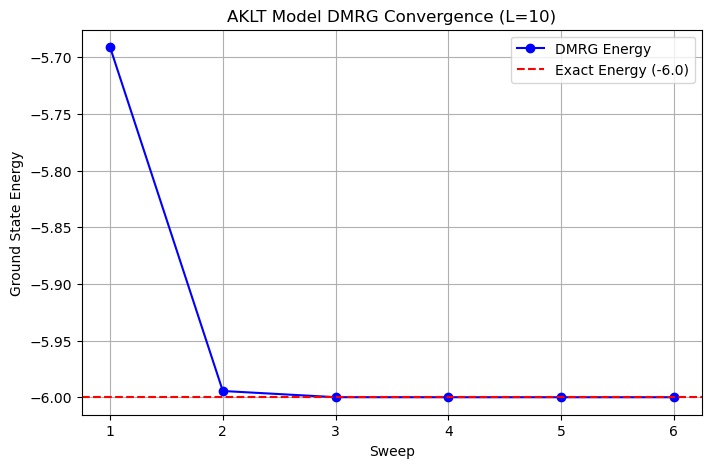

In [8]:
# Cell 8
# AKLT Implementation Verification (L=10)
L_aklt = 10
D_max = 10
eps = 1e-8

print("=== Running AKLT Model (L=10) ===")
W_aklt = BuildAKLTMPO(L_aklt)
M_init_aklt = generate_random_mps(L_aklt, d=3, D=2)

E_aklt, M_opt_aklt, energies_aklt = SingleSiteDMRG(W_aklt, M_init_aklt, D_max, eps)
exact_aklt = -(L_aklt - 1) * (2/3)
var_aklt = ComputeVariance(M_opt_aklt, W_aklt, E_aklt)

print(f"Final Energy (DMRG) : {E_aklt:.10f}")
print(f"Exact Target Energy : {exact_aklt:.10f}")
print(f"Energy Variance     : {var_aklt:.3e}")

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(energies_aklt)+1), energies_aklt, 'bo-', label="DMRG Energy")
plt.axhline(exact_aklt, color='r', linestyle='--', label="Exact Energy (-6.0)")
plt.xlabel('Sweep')
plt.ylabel('Ground State Energy')
plt.title(f'AKLT Model DMRG Convergence (L={L_aklt})')
plt.legend()
plt.grid(True)
plt.savefig('figureAKLT/AKLT_convergence.png')
plt.show()

In [11]:
# Cell 10
def ApplyHeff2Site(v, L_env, W1, W2, R_env):
    """Section 5.3: Two-Site Effective Hamiltonian"""
    # L_env: (b, x, y), W1: (b, B, s, t), W2: (B, C, v, u), R_env: (C, X, Y)
    # v shape: (x, t, u, X) where x=left_bond, t=site1_in, u=site2_in, X=right_bond
    V = v.reshape((L_env.shape[1], W1.shape[3], W2.shape[3], R_env.shape[1]))
    
    # Contract L_env with V
    T1 = np.einsum('bxy, xtuX -> bytuX', L_env, V)
    
    # Contract with W1 (site 1)
    T2 = np.einsum('bytuX, bBst -> yBuXs', T1, W1)
    
    # Contract with W2 (site 2)
    T3 = np.einsum('yBuXs, BCvu -> yCXsv', T2, W2)
    
    # Contract with R_env
    result = np.einsum('yCXsv, CXY -> ysvY', T3, R_env)
    
    return result.ravel()

def solve_local_Heff_2site(L_env, W1, W2, R_env, Theta_guess):
    """Iterative eigensolver wrapper for Two-Site DMRG"""
    dim1 = L_env.shape[1]
    d1 = W1.shape[2]
    d2 = W2.shape[2]
    dim2 = R_env.shape[1]
    dim = dim1 * d1 * d2 * dim2
    
    def matvec(v):
        return ApplyHeff2Site(v, L_env, W1, W2, R_env)
        
    H_op = LinearOperator((dim, dim), matvec=matvec, dtype=np.complex128)
    
    # Dense fallback for small dimensions
    if dim <= 16:
        H_dense = np.zeros((dim, dim), dtype=np.complex128)
        for i in range(dim):
            basis = np.zeros(dim, dtype=np.complex128)
            basis[i] = 1.0
            H_dense[:, i] = matvec(basis)
        H_dense = 0.5 * (H_dense + H_dense.conj().T) 
        vals, vecs = np.linalg.eigh(H_dense)
        return vals[0].real, vecs[:, 0]
    else:
        v0 = Theta_guess.ravel()
        try:
            vals, vecs = eigsh(H_op, k=1, which='SA', v0=v0, tol=1e-10)
            return vals[0].real, vecs[:, 0]
        except:
            H_dense = np.zeros((dim, dim), dtype=np.complex128)
            for i in range(dim):
                basis = np.zeros(dim, dtype=np.complex128)
                basis[i] = 1.0
                H_dense[:, i] = matvec(basis)
            H_dense = 0.5 * (H_dense + H_dense.conj().T)
            vals, vecs = np.linalg.eigh(H_dense)
            return vals[0].real, vecs[:, 0]

def TwoSiteDMRG(W, M_init, D_max, eps, sweeps=5):
    """Algorithm 11: Two-Site DMRG (First 3-5 sweeps to grow D)"""
    L = len(W)
    d = W[0].shape[2]
    
    M = RightCanonicalize(M_init)
    
    L_env = [None] * L
    R_env = [None] * L
    L_env[0] = np.ones((1, 1, 1), dtype=np.complex128)
    R_env[L-1] = np.ones((1, 1, 1), dtype=np.complex128)
    
    for i in range(L-1, 0, -1):
        R_env[i-1] = UpdateRightEnv(R_env[i], M[i], W[i])
        
    energies = []
    
    for sweep in range(sweeps):
        # Right sweep
        for i in range(0, L-1):
            # Contract two sites
            Theta = np.einsum('xsa, ayb -> xsyb', M[i], M[i+1])
            
            E, v = solve_local_Heff_2site(L_env[i], W[i], W[i+1], R_env[i+1], Theta)
            Theta_opt = v.reshape((L_env[i].shape[1] * d, d * R_env[i+1].shape[1]))
            
            # Truncate and split
            u, s, vh, eta = TruncateBond(Theta_opt, D_max, eps)
            
            M[i] = u.reshape((L_env[i].shape[1], d, len(s)))
            M[i+1] = (np.diag(s) @ vh).reshape((len(s), d, R_env[i+1].shape[1]))
            
            # Update left environment
            L_env[i+1] = UpdateLeftEnv(L_env[i], M[i], W[i])
            
        # Left sweep
        for i in range(L-2, -1, -1):
            Theta = np.einsum('xsa, ayb -> xsyb', M[i], M[i+1])
            
            E, v = solve_local_Heff_2site(L_env[i], W[i], W[i+1], R_env[i+1], Theta)
            Theta_opt = v.reshape((L_env[i].shape[1] * d, d * R_env[i+1].shape[1]))
            
            u, s, vh, eta = TruncateBond(Theta_opt, D_max, eps)
            
            M[i] = (u @ np.diag(s)).reshape((L_env[i].shape[1], d, len(s)))
            M[i+1] = vh.reshape((len(s), d, R_env[i+1].shape[1]))
            
            # Update right environment
            R_env[i] = UpdateRightEnv(R_env[i+1], M[i+1], W[i+1])
            
        energies.append(E)
        current_max_D = max(m.shape[2] for m in M[:-1])
        print(f"Two-Site Sweep {sweep+1}: E = {E:.10f}, Max Bond D = {current_max_D}")
        
    return E, M, energies

=== Running Two-Site + Single-Site DMRG on Heisenberg (L=20) ===

--- Phase 1: Two-Site DMRG (Growing Bond Dimension) ---
Two-Site Sweep 1: E = -8.5976601059, Max Bond D = 4
Two-Site Sweep 2: E = -8.6822659128, Max Bond D = 16
Two-Site Sweep 3: E = -8.6824733113, Max Bond D = 30
Two-Site Sweep 4: E = -8.6824733113, Max Bond D = 30
Two-Site Sweep 5: E = -8.6824733113, Max Bond D = 30

--- Phase 2: Single-Site DMRG (Final Convergence) ---
Converged at sweep 2

Final Extrapolated Energy: -8.772 (from notes)
Computed Final Energy    : -8.6824733114
Final Variance           : 9.060e-08


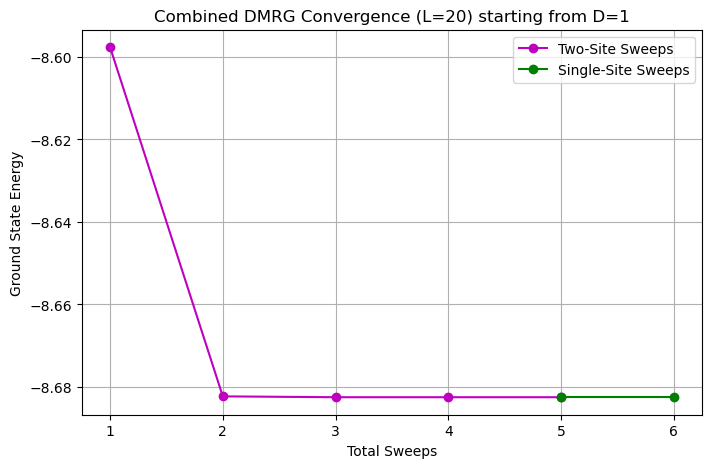

In [12]:
# Cell 11
L_large = 20
D_max_2site = 30
eps = 1e-8

print("=== Running Two-Site + Single-Site DMRG on Heisenberg (L=20) ===")
W_large = BuildHeisenbergMPO(L_large)

# Intentionally start with the worst possible state (D=1)
M_init_D1 = generate_random_mps(L_large, d=2, D=1)

print("\n--- Phase 1: Two-Site DMRG (Growing Bond Dimension) ---")
E_2site, M_grown, energies_2site = TwoSiteDMRG(W_large, M_init_D1, D_max_2site, eps, sweeps=5)

print("\n--- Phase 2: Single-Site DMRG (Final Convergence) ---")
E_final, M_opt, energies_1site = SingleSiteDMRG(W_large, M_grown, D_max_2site, eps, max_sweeps=10)

var_final = ComputeVariance(M_opt, W_large, E_final)
print(f"\nFinal Extrapolated Energy: -8.772 (from notes)")
print(f"Computed Final Energy    : {E_final:.10f}")
print(f"Final Variance           : {var_final:.3e}")

# Plotting the combined convergence
all_energies = energies_2site + energies_1site
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), energies_2site, 'mo-', label="Two-Site Sweeps")
plt.plot(range(5, 5 + len(energies_1site)), [energies_2site[-1]] + energies_1site[:-1], 'go-', label="Single-Site Sweeps")
plt.xlabel('Total Sweeps')
plt.ylabel('Ground State Energy')
plt.title(f'Combined DMRG Convergence (L={L_large}) starting from D=1')
plt.legend()
plt.grid(True)
plt.savefig('figureAKLT/Heisenberg_2site_convergence.png')
plt.show()

In [14]:
# Cell 12
def UpdateOverlapLeft(L_old, psi_M, phi_M):
    """Left environment for state overlap <psi|phi>"""
    # L_old: (psi_left, phi_left)
    # psi_M: (psi_left, s, psi_right)
    # phi_M: (phi_left, s, phi_right)
    return np.einsum('xp, xsy, psq -> yq', L_old, psi_M.conj(), phi_M)

def UpdateOverlapRight(R_old, psi_M, phi_M):
    """Right environment for state overlap <psi|phi>"""
    # R_old: (psi_right, phi_right)
    return np.einsum('yq, xsy, psq -> xp', R_old, psi_M.conj(), phi_M)

def VariationalCompress(psi, D_target, sweeps=5):
    """Algorithm 13: Variational Compression to minimize || |psi> - |phi> ||^2"""
    L = len(psi)
    d = psi[0].shape[1]
    
    # 1. --- Smart Initialization via SVD Truncation ---
    # Copy the target state to avoid modifying it
    phi = [m.copy() for m in psi]
    phi = RightCanonicalize(phi)
    
    # Sweep left-to-right to do a naive SVD truncation down to D_target
    for i in range(L-1):
        M_mat = phi[i].reshape(phi[i].shape[0] * d, phi[i].shape[2])
        u, s, vh, _ = TruncateBond(M_mat, D_target, eps_rel=0.0) 
        phi[i] = u.reshape((phi[i].shape[0], d, len(s)))
        phi[i+1] = np.einsum('ab, bsc -> asc', np.diag(s) @ vh, phi[i+1])
        
    phi = RightCanonicalize(phi)
    
    # 2. --- Variational Optimization Sweeps ---
    L_env = [None] * L
    R_env = [None] * L
    L_env[0] = np.ones((1, 1), dtype=np.complex128)
    R_env[L-1] = np.ones((1, 1), dtype=np.complex128)
    
    for i in range(L-1, 0, -1):
        R_env[i-1] = UpdateOverlapRight(R_env[i], psi[i], phi[i])
        
    for sweep in range(sweeps):
        # Right sweep
        for i in range(0, L-1):
            # T is the projection. We MUST conjugate L_env and R_env 
            # to properly map <psi|phi> into <phi|psi> for the update!
            T = np.einsum('xp, xsy, yq -> psq', L_env[i].conj(), psi[i], R_env[i].conj())
            
            T_mat = T.reshape(T.shape[0] * d, T.shape[2])
            u, s, vh, _ = TruncateBond(T_mat, D_target, eps_rel=1e-14)
            
            phi[i] = u.reshape((T.shape[0], d, len(s)))
            phi[i+1] = np.einsum('ab, bsc -> asc', np.diag(s) @ vh, phi[i+1])
            
            L_env[i+1] = UpdateOverlapLeft(L_env[i], psi[i], phi[i])
            
        # Optimize last site and turnaround
        T = np.einsum('xp, xsy, yq -> psq', L_env[L-1].conj(), psi[L-1], R_env[L-1].conj())
        phi[L-1] = T
        
        # Left sweep
        for i in range(L-1, 0, -1):
            T = np.einsum('xp, xsy, yq -> psq', L_env[i].conj(), psi[i], R_env[i].conj())
            
            T_mat = T.reshape(T.shape[0], d * T.shape[2])
            u, s, vh, _ = TruncateBond(T_mat, D_target, eps_rel=1e-14)
            
            phi[i] = vh.reshape((len(s), d, T.shape[2]))
            phi[i-1] = np.einsum('xsa, ab -> xsb', phi[i-1], u @ np.diag(s))
            
            R_env[i-1] = UpdateOverlapRight(R_env[i], psi[i], phi[i])
            
    # Normalize the final state to prevent floating point drift
    norm = np.sqrt(ComputeOverlap(phi, phi).real)
    phi[0] = phi[0] / norm
    
    return phi

# --- Testing the Compression ---
print("=== Testing Variational Compression ===")
D_compressed = 10
print(f"Compressing Heisenberg ground state from D={D_max_2site} down to D={D_compressed}...")

# Run compression
M_compressed = VariationalCompress(M_opt, D_compressed, sweeps=5)

# Calculate fidelities
overlap = ComputeOverlap(M_opt, M_compressed)
norm_opt = ComputeOverlap(M_opt, M_opt).real
norm_comp = ComputeOverlap(M_compressed, M_compressed).real

fidelity = (abs(overlap)**2) / (norm_opt * norm_comp)
E_compressed = ComputeOverlap(ApplyMPOtoMPS(W_large, M_compressed), M_compressed).real / norm_comp

print(f"Original Energy (D=30)   : {E_final:.10f}")
print(f"Compressed Energy (D=10) : {E_compressed:.10f}")
print(f"State Fidelity |<psi|phi>|^2 : {fidelity:.6f}")

=== Testing Variational Compression ===
Compressing Heisenberg ground state from D=30 down to D=10...
Original Energy (D=30)   : -8.6824733114
Compressed Energy (D=10) : -8.6822490350
State Fidelity |<psi|phi>|^2 : 0.999920


=== Measuring Observables (Heisenberg L=20) ===


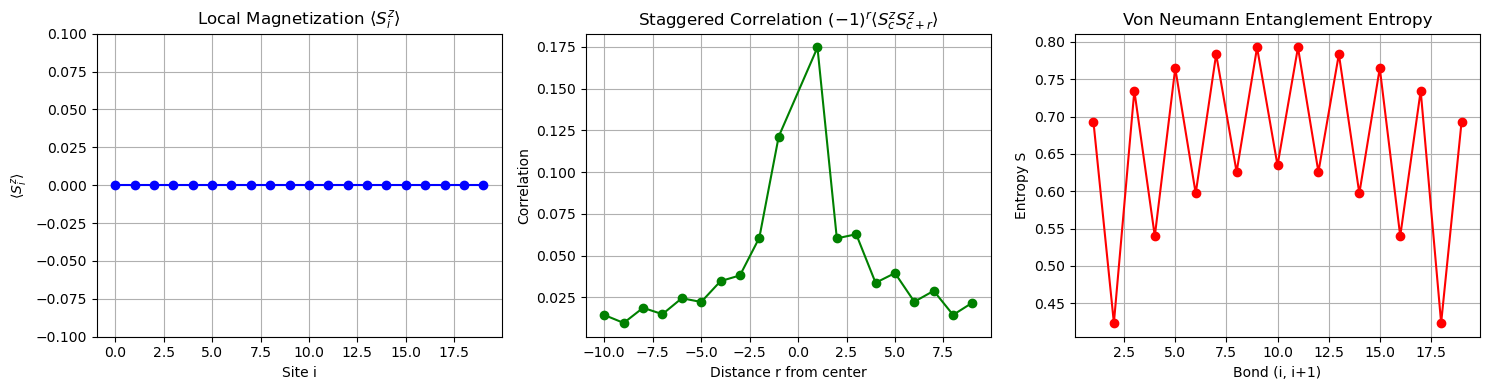

In [16]:
# Cell 13
def Measure1Site(M, op, i):
    """Measure single-site observable: <psi| op_i |psi> / <psi|psi>"""
    E = np.ones((1, 1), dtype=np.complex128)
    for k in range(len(M)):
        if k == i:
            # Contract with the operator 'op' at site i
            # st: s=bra_physical, t=ket_physical
            E = np.einsum('xy, xsa, st, ytb -> ab', E, M[k].conj(), op, M[k])
        else:
            # Standard identity overlap (fixed ysb)
            E = np.einsum('xy, xsa, ysb -> ab', E, M[k].conj(), M[k])
            
    norm = ComputeOverlap(M, M).real
    return (E[0, 0] / norm).real

def Measure2Site(M, op1, op2, i, j):
    """Measure two-site correlation: <psi| op1_i op2_j |psi> / <psi|psi>"""
    if i > j: # Ensure i is always the leftmost site
        i, j = j, i
        op1, op2 = op2, op1
        
    E = np.ones((1, 1), dtype=np.complex128)
    for k in range(len(M)):
        if k == i:
            E = np.einsum('xy, xsa, st, ytb -> ab', E, M[k].conj(), op1, M[k])
        elif k == j:
            E = np.einsum('xy, xsa, st, ytb -> ab', E, M[k].conj(), op2, M[k])
        else:
            # Standard identity overlap (fixed ysb)
            E = np.einsum('xy, xsa, ysb -> ab', E, M[k].conj(), M[k])
            
    norm = ComputeOverlap(M, M).real
    return (E[0, 0] / norm).real

def ComputeEntanglementEntropy(M):
    """Compute the Von Neumann Entanglement Entropy S = -sum(s^2 ln(s^2)) at each bond"""
    L = len(M)
    M_temp = [m.copy() for m in M]
    entropies = []
    
    # 1. Bring state to pure Right-Canonical form
    M_temp = RightCanonicalize(M_temp)
    
    # 2. Sweep left-to-right, applying SVD to extract the exact Schmidt values
    for i in range(L-1):
        M_mat = M_temp[i].reshape(-1, M_temp[i].shape[2])
        
        # Perform SVD (no truncation)
        u, s, vh, _ = TruncateBond(M_mat, D_max=1000, eps_rel=1e-14)
        
        # Normalize singular values (Schmidt coefficients)
        s = s / np.linalg.norm(s)
        
        # Calculate Von Neumann Entropy
        S = -np.sum((s**2) * np.log(s**2 + 1e-16)) 
        entropies.append(S)
        
        # Shift the gauge to the next site to keep sweeping
        M_temp[i] = u.reshape((M_temp[i].shape[0], M_temp[i].shape[1], len(s)))
        M_temp[i+1] = np.einsum('ab, bsc -> asc', np.diag(s) @ vh, M_temp[i+1])
        
    return entropies

# --- Run Measurements on the Heisenberg Ground State ---
print("=== Measuring Observables (Heisenberg L=20) ===")
Sz = np.array([[0.5, 0], [0, -0.5]], dtype=np.complex128)

# 1. Measure Local Magnetization <Sz_i>
sz_exp = [Measure1Site(M_opt, Sz, i) for i in range(L_large)]

# 2. Measure Spin-Spin Correlation <Sz_c Sz_j> from the center site
center = L_large // 2
corr = []
distances = []
for j in range(L_large):
    if j != center:
        # Multiply by (-1)^|i-j| to remove the staggered antiferromagnetic sign
        sign = (-1)**abs(center - j)
        val = Measure2Site(M_opt, Sz, Sz, center, j)
        corr.append(sign * val)
        distances.append(j - center)

# 3. Measure Entanglement Entropy
entropies = ComputeEntanglementEntropy(M_opt)

# --- Plotting the Physics ---
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Local Magnetization
axs[0].plot(range(L_large), sz_exp, 'bo-')
axs[0].set_title(r"Local Magnetization $\langle S^z_i \rangle$")
axs[0].set_xlabel("Site i")
axs[0].set_ylabel(r"$\langle S^z_i \rangle$")
axs[0].grid(True)
axs[0].set_ylim(-0.1, 0.1) 

# Plot 2: Correlation Decay
axs[1].plot(distances, corr, 'go-')
axs[1].set_title(r"Staggered Correlation $(-1)^{r} \langle S^z_c S^z_{c+r} \rangle$")
axs[1].set_xlabel("Distance r from center")
axs[1].set_ylabel("Correlation")
axs[1].grid(True)

# Plot 3: Entanglement Entropy
axs[2].plot(range(1, L_large), entropies, 'ro-')
axs[2].set_title("Von Neumann Entanglement Entropy")
axs[2].set_xlabel("Bond (i, i+1)")
axs[2].set_ylabel("Entropy S")
axs[2].grid(True)

plt.tight_layout()
plt.savefig('figureAKLT/Heisenberg_Observables.png')
plt.show()